<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/Books_categorizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

booksDF = pd.read_csv('cleaned_books_dataset.csv')
booksDF['cleaned_description'] = booksDF['cleaned_description'].fillna('')

In [ ]:
booksDF.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...


In [ ]:
booksDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4895 entries, 0 to 4894
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   isbn13               4895 non-null   int64  
 1   isbn10               4895 non-null   object 
 2   title                4895 non-null   object 
 3   authors              4895 non-null   object 
 4   categories           4895 non-null   object 
 5   description          4895 non-null   object 
 6   thumbnail            4895 non-null   object 
 7   average_rating       4895 non-null   float64
 8   num_pages            4895 non-null   float64
 9   cleaned_description  4895 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 382.6+ KB


In [ ]:
binary_mapping = {
    'Fiction': 'fiction',
    'Juvenile Fiction': 'fiction',
    'Comics & Graphic Novels': 'fiction',
    'Drama': 'fiction',
    'Poetry': 'fiction',
    'Biography & Autobiography': 'nonfiction',
    'History': 'nonfiction',
    'Literary Criticism': 'nonfiction',
    'Philosophy': 'nonfiction',
    'Religion': 'nonfiction',
    'Juvenile Nonfiction': 'nonfiction'
}
booksDF['binary_category'] = booksDF['categories'].map(binary_mapping)

In [ ]:
train_df = booksDF.dropna(subset=['binary_category']).copy()
X = train_df['cleaned_description']
y = train_df['binary_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

binary_model = LinearSVC(class_weight='balanced', C=0.5, random_state=42)
binary_model.fit(X_train_vec, y_train)

LinearSVC(C=0.5, class_weight='balanced', random_state=42)

In [ ]:
y_pred = binary_model.predict(X_test_vec)

In [ ]:
print("--- NEW BINARY MODEL EVALUATION ---")
accuracy_score = accuracy_score(y_test, y_pred) * 100
print(f"Overall Accuracy: {accuracy_score}\n")
print(classification_report(y_test, y_pred))

--- NEW BINARY MODEL EVALUATION ---
Overall Accuracy: 85.49540347293157

              precision    recall  f1-score   support

     fiction       0.91      0.89      0.90       724
  nonfiction       0.71      0.75      0.73       255

    accuracy                           0.85       979
   macro avg       0.81      0.82      0.81       979
weighted avg       0.86      0.85      0.86       979



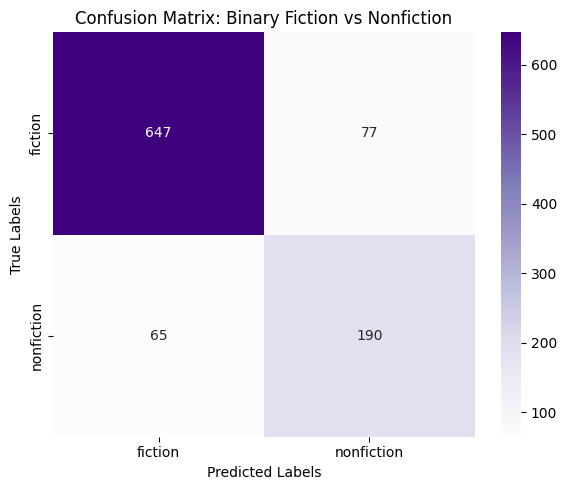

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=binary_model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=binary_model.classes_, yticklabels=binary_model.classes_, ax=ax)
ax.set_title('Confusion Matrix: Binary Fiction vs Nonfiction')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.tight_layout()
plt.show()

In [ ]:
X_full_vec = vectorizer.transform(booksDF['cleaned_description'])
booksDF['simple_categories_binary'] = binary_model.predict(X_full_vec)

Predicting across the entire dataset...


In [ ]:
booksDF.drop(columns=['binary_category'], errors='ignore', inplace=True)
booksDF.to_csv('cleaned_books_dataset_binary_category.csv', index=False)

In [ ]:
BinaryBooks = pd.read_csv('cleaned_books_dataset_binary_category.csv')
BinaryBooks.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction


In [ ]:
BinaryBooks["simple_categories_binary"].value_counts()

,count
simple_categories_binary,
fiction,3568
nonfiction,1327
